# TP – CNN "from scratch" vs Transfert Learning (Cats vs Dogs)

**Objectif :** Comparer un modèle CNN entraîné *from scratch* et un modèle en transfert d'apprentissage sur le jeu de données Cats vs Dogs.

**Structure :**
- Partie 0 : Configuration & imports
- Partie 1 : Chargement des données & augmentation
- Partie 2 : Expérience A – CNN from scratch
- Partie 3 : Expérience B – Transfer Learning (ResNet18)
- Partie 4 : Comparaison & analyse


## Partie 0 – Configuration & imports

In [ ]:
# ─────────────────────────────────────────────
# 0.1  Imports
# ─────────────────────────────────────────────
import os, random, time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
)

# ─────────────────────────────────────────────
# 0.2  Reproductibilité
# ─────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ─────────────────────────────────────────────
# 0.3  Appareil GPU / CPU
# ─────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f'Appareil utilisé : {DEVICE}')

Appareil utilisé : mps


## Partie 1 – Chargement des données & augmentation

In [ ]:
# ─────────────────────────────────────────────
# 1.1  Répertoire des données
# ─────────────────────────────────────────────


DATA_DIR = 'Cat_Dog_data'   

IMG_SIZE   = 224   
BATCH_SIZE = 64

# ─────────────────────────────────────────────
# 1.2  Transformations 
# ─────────────────────────────────────────────

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),      
    transforms.RandomHorizontalFlip(),           
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.2),      
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),             
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# ─────────────────────────────────────────────
# 1.3  Datasets & DataLoaders
# ─────────────────────────────────────────────
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=train_transforms)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'),  transform=test_transforms)

is_mps = (DEVICE.type == 'mps')

trainloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,          
    pin_memory=False        
)
testloader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=False
)

CLASS_NAMES = train_dataset.classes
print(f'Classes : {CLASS_NAMES}')
print(f'Train : {len(train_dataset)} images | Test : {len(test_dataset)} images')

Classes : ['cat', 'dog']
Train : 22500 images | Test : 2500 images


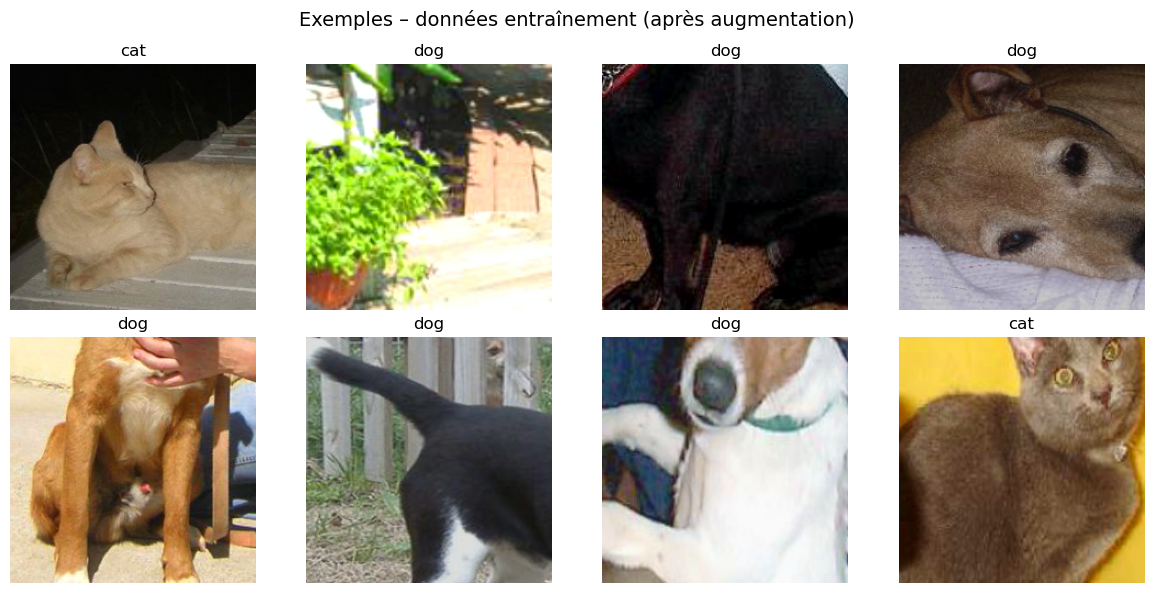

In [17]:
# ─────────────────────────────────────────────
# 1.4  Visualisation de quelques images d'entraînement
# ─────────────────────────────────────────────
def imshow(img, ax=None, title=None):
    """Affiche un Tensor image (dé-normalisation ImageNet)."""
    if ax is None:
        fig, ax = plt.subplots()
    img = img.numpy().transpose((1, 2, 0))
    img = np.array(STD) * img + np.array(MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    if title:
        ax.set_title(title)
    ax.axis('off')

images, labels = next(iter(trainloader))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    imshow(images[i], ax=ax, title=CLASS_NAMES[labels[i]])
plt.suptitle('Exemples – données entraînement (après augmentation)', fontsize=14)
plt.tight_layout()
plt.show()

## Partie 2 – Expérience A : CNN *from scratch*

In [ ]:
# ─────────────────────────────────────────────
# 2.1  Architecture CNN
# ─────────────────────────────────────────────


class CatDogCNN(nn.Module):
    def __init__(self, num_classes=2, dropout_p=0.5):
        super().__init__()

        # Bloc 1 : 3 -> 32 canaux  |  224×224 -> 112×112
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25)
        )

        # Bloc 2 : 32 -> 64 canaux  |  112×112 -> 56×56
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25)
        )

        # Bloc 3 : 64 -> 128 canaux  |  56×56 -> 28×28
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25)
        )

        # Classifieur : AdaptiveAvgPool réduit 128×28×28 -> 128×1×1
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  
            nn.Flatten(),                   
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(256, num_classes)     
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)


model_scratch = CatDogCNN(num_classes=2).to(DEVICE)
print(model_scratch)
total_params = sum(p.numel() for p in model_scratch.parameters() if p.requires_grad)
print(f'\nParamètres entraînables : {total_params:,}')

CatDogCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)


In [19]:
# ─────────────────────────────────────────────
# 2.2  Fonction d'entraînement générique
# ─────────────────────────────────────────────
def train_model(model, trainloader, testloader, criterion, optimizer,
                scheduler=None, n_epochs=10, model_name='model'):
    """
    Entraîne un modèle et retourne l'historique des métriques.
    Sauvegarde le meilleur modèle sur validation.
    """
    history = {'train_loss': [], 'val_loss': [],
               'train_acc': [],  'val_acc': [],
               'val_precision': [], 'val_recall': []}

    best_val_acc = 0.0
    save_path    = f'{model_name}_best.pth'

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()

        # ── Entraînement ──
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, lbls in trainloader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            _, preds = out.max(1)
            correct  += preds.eq(lbls).sum().item()
            total    += lbls.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total

        # ── Validation ──
        model.eval()
        val_loss, all_preds, all_labels = 0.0, [], []
        with torch.no_grad():
            for imgs, lbls in testloader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                out  = model(imgs)
                loss = criterion(out, lbls)
                val_loss += loss.item() * imgs.size(0)
                _, preds = out.max(1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(lbls.cpu().numpy())

        val_loss      = val_loss / len(testloader.dataset)
        val_acc       = accuracy_score(all_labels, all_preds)
        val_precision = precision_score(all_labels, all_preds, zero_division=0)
        val_recall    = recall_score(all_labels, all_preds, zero_division=0)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_precision'].append(val_precision)
        history['val_recall'].append(val_recall)

        if scheduler:
            scheduler.step()

        # Sauvegarde meilleur modèle
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

        elapsed = time.time() - t0
        print(f'Epoch [{epoch:2d}/{n_epochs}]  '
              f'Loss train:{train_loss:.4f} val:{val_loss:.4f}  '
              f'Acc train:{train_acc:.3f} val:{val_acc:.3f}  '
              f'({elapsed:.1f}s)')

    print(f'\n✔ Meilleur modèle sauvegardé : {save_path}  (val_acc={best_val_acc:.4f})')
    return history, save_path

In [20]:
# ─────────────────────────────────────────────
# 2.3  Entraînement – Scratch avec SGD puis Adam
# ─────────────────────────────────────────────
N_EPOCHS = 15
criterion = nn.CrossEntropyLoss()

# --- Optimiseur 1 : SGD avec momentum ---
print('=== Scratch – SGD ===')
model_scratch_sgd = CatDogCNN(num_classes=2).to(DEVICE)
optimizer_sgd     = optim.SGD(model_scratch_sgd.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
scheduler_sgd     = StepLR(optimizer_sgd, step_size=5, gamma=0.5)
hist_scratch_sgd, _ = train_model(
    model_scratch_sgd, trainloader, testloader, criterion,
    optimizer_sgd, scheduler_sgd, N_EPOCHS, 'scratch_sgd'
)

# --- Optimiseur 2 : Adam ---
print('\n=== Scratch – Adam ===')
model_scratch_adam = CatDogCNN(num_classes=2).to(DEVICE)
optimizer_adam     = optim.Adam(model_scratch_adam.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_adam     = StepLR(optimizer_adam, step_size=5, gamma=0.5)
hist_scratch_adam, path_scratch_best = train_model(
    model_scratch_adam, trainloader, testloader, criterion,
    optimizer_adam, scheduler_adam, N_EPOCHS, 'scratch_adam'
)

=== Scratch – SGD ===
Epoch [ 1/15]  Loss train:0.7205 val:0.6887  Acc train:0.554 val:0.616  (175.7s)
Epoch [ 2/15]  Loss train:0.6988 val:0.6454  Acc train:0.578 val:0.614  (199.4s)
Epoch [ 3/15]  Loss train:0.6846 val:0.6328  Acc train:0.587 val:0.644  (176.3s)
Epoch [ 4/15]  Loss train:0.6737 val:0.6305  Acc train:0.598 val:0.637  (174.9s)
Epoch [ 5/15]  Loss train:0.6671 val:0.6273  Acc train:0.603 val:0.650  (173.7s)
Epoch [ 6/15]  Loss train:0.6579 val:0.6252  Acc train:0.616 val:0.649  (176.4s)
Epoch [ 7/15]  Loss train:0.6444 val:0.6125  Acc train:0.631 val:0.678  (173.4s)
Epoch [ 8/15]  Loss train:0.6360 val:0.6167  Acc train:0.633 val:0.681  (173.3s)
Epoch [ 9/15]  Loss train:0.6397 val:0.6064  Acc train:0.636 val:0.676  (176.6s)
Epoch [10/15]  Loss train:0.6309 val:0.5971  Acc train:0.644 val:0.695  (178.9s)
Epoch [11/15]  Loss train:0.6231 val:0.5898  Acc train:0.656 val:0.702  (179.5s)
Epoch [12/15]  Loss train:0.6157 val:0.5754  Acc train:0.659 val:0.713  (174.6s)
Epoch 

## Partie 3 – Expérience B : Transfer Learning (ResNet18)

In [ ]:
# ─────────────────────────────────────────────
# 3.1  Modèle ResNet18 pré-entraîné (ImageNet)
# ─────────────────────────────────────────────

def build_resnet18_transfer(num_classes=2, freeze_backbone=False):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        # Geler toutes les couches sauf le classifieur
        for name, param in model.named_parameters():
            if 'fc' not in name:
                param.requires_grad = False

    # Remplacer le classifieur
    in_features = model.fc.in_features   # 512 pour ResNet18
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

model_tl = build_resnet18_transfer(num_classes=2, freeze_backbone=False).to(DEVICE)
trainable = sum(p.numel() for p in model_tl.parameters() if p.requires_grad)
print(f'Paramètres entraînables : {trainable:,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/syannick/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:17<00:00, 2.61MB/s]


Paramètres entraînables : 11,177,538


In [ ]:
# ─────────────────────────────────────────────
# 3.2  Entraînement – Transfer Learning avec SGD et Adam
# ─────────────────────────────────────────────

# --- Optimiseur 1 : SGD ---
print('=== Transfer Learning – SGD ===')
model_tl_sgd  = build_resnet18_transfer(num_classes=2).to(DEVICE)
opt_tl_sgd    = optim.SGD(model_tl_sgd.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-4)
sched_tl_sgd  = StepLR(opt_tl_sgd, step_size=5, gamma=0.5)
hist_tl_sgd, _ = train_model(
    model_tl_sgd, trainloader, testloader, criterion,
    opt_tl_sgd, sched_tl_sgd, N_EPOCHS, 'tl_sgd'
)

# --- Optimiseur 2 : Adam ---
print('\n=== Transfer Learning – Adam ===')
model_tl_adam  = build_resnet18_transfer(num_classes=2).to(DEVICE)
opt_tl_adam    = optim.Adam(model_tl_adam.parameters(), lr=1e-4, weight_decay=1e-4)
sched_tl_adam  = StepLR(opt_tl_adam, step_size=5, gamma=0.5)
hist_tl_adam, path_tl_best = train_model(
    model_tl_adam, trainloader, testloader, criterion,
    opt_tl_adam, sched_tl_adam, N_EPOCHS, 'tl_adam'
)

=== Transfer Learning – SGD ===
Epoch [ 1/15]  Loss train:0.1809 val:0.0353  Acc train:0.918 val:0.987  (144.6s)
Epoch [ 2/15]  Loss train:0.1148 val:0.0317  Acc train:0.951 val:0.986  (141.9s)
Epoch [ 3/15]  Loss train:0.1000 val:0.0272  Acc train:0.957 val:0.989  (164.9s)
Epoch [ 4/15]  Loss train:0.0989 val:0.0247  Acc train:0.958 val:0.991  (154.2s)
Epoch [ 5/15]  Loss train:0.0920 val:0.0242  Acc train:0.959 val:0.992  (144.2s)
Epoch [ 6/15]  Loss train:0.0853 val:0.0238  Acc train:0.965 val:0.991  (141.2s)
Epoch [ 7/15]  Loss train:0.0830 val:0.0237  Acc train:0.966 val:0.990  (141.5s)
Epoch [ 8/15]  Loss train:0.0844 val:0.0230  Acc train:0.965 val:0.990  (141.6s)
Epoch [ 9/15]  Loss train:0.0787 val:0.0218  Acc train:0.966 val:0.992  (142.1s)
Epoch [10/15]  Loss train:0.0839 val:0.0210  Acc train:0.966 val:0.991  (143.4s)
Epoch [11/15]  Loss train:0.0760 val:0.0215  Acc train:0.968 val:0.992  (145.0s)
Epoch [12/15]  Loss train:0.0772 val:0.0197  Acc train:0.967 val:0.991  (148.

## Partie 4 – Comparaison & analyse

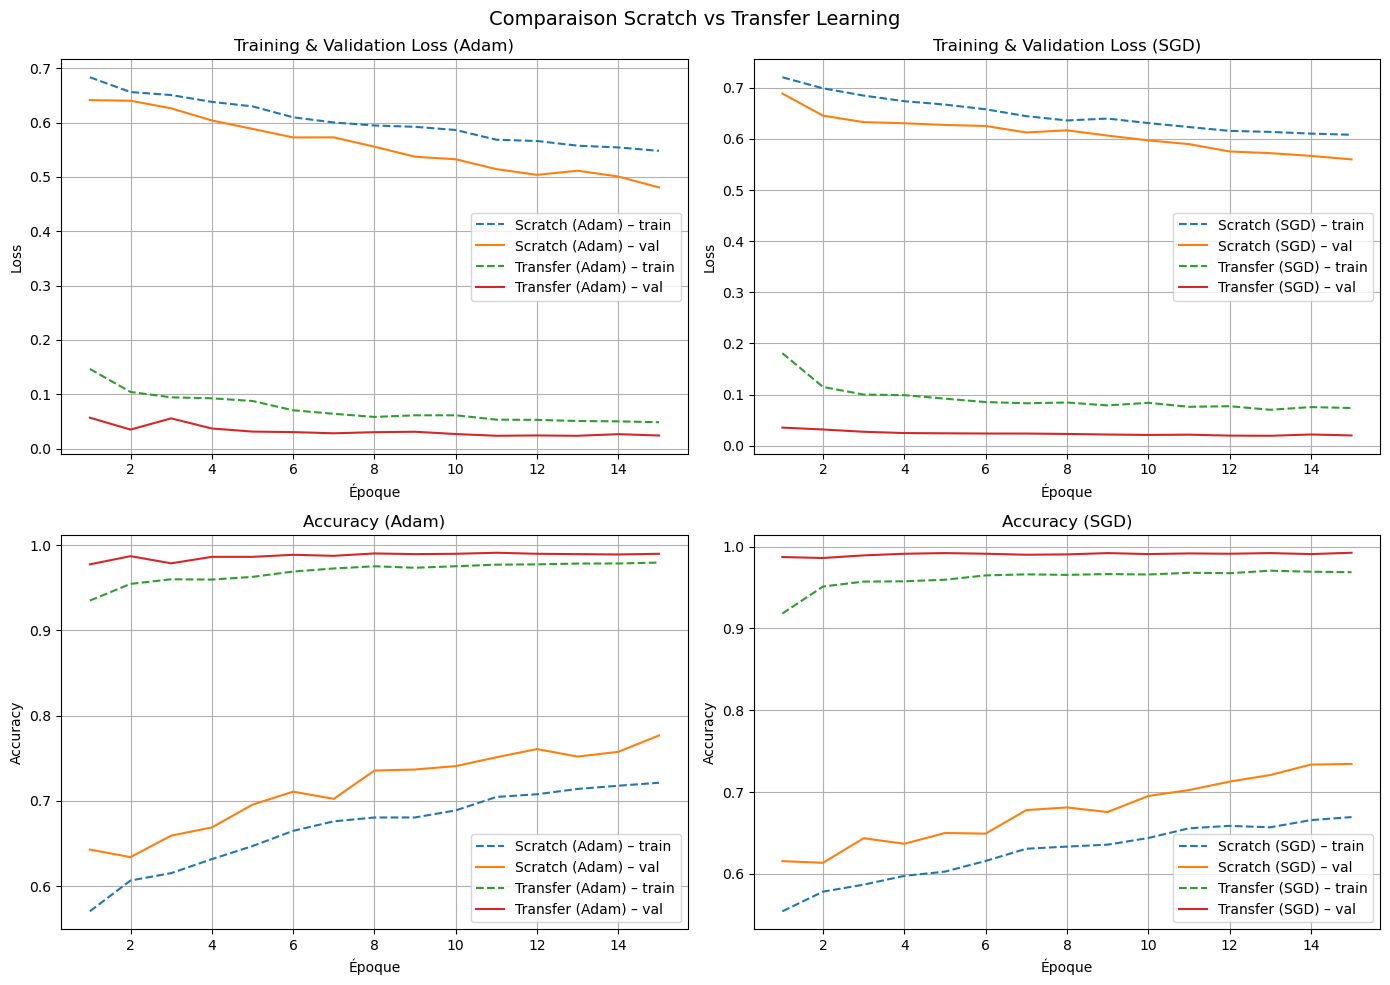

In [23]:
# ─────────────────────────────────────────────
# 4.1  Courbes Loss & Accuracy
# ─────────────────────────────────────────────
epochs = range(1, N_EPOCHS + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
for ax, hist, label in [
    (axes[0,0], hist_scratch_adam, 'Scratch (Adam)'),
    (axes[0,0], hist_tl_adam,      'Transfer (Adam)'),
]:
    ax.plot(epochs, hist['train_loss'], '--', label=f'{label} – train')
    ax.plot(epochs, hist['val_loss'],   '-',  label=f'{label} – val')
axes[0,0].set_title('Training & Validation Loss (Adam)')
axes[0,0].set_xlabel('Époque'); axes[0,0].set_ylabel('Loss')
axes[0,0].legend(); axes[0,0].grid(True)

for ax, hist, label in [
    (axes[0,1], hist_scratch_sgd, 'Scratch (SGD)'),
    (axes[0,1], hist_tl_sgd,      'Transfer (SGD)'),
]:
    ax.plot(epochs, hist['train_loss'], '--', label=f'{label} – train')
    ax.plot(epochs, hist['val_loss'],   '-',  label=f'{label} – val')
axes[0,1].set_title('Training & Validation Loss (SGD)')
axes[0,1].set_xlabel('Époque'); axes[0,1].set_ylabel('Loss')
axes[0,1].legend(); axes[0,1].grid(True)

# Accuracy
for ax, hist, label in [
    (axes[1,0], hist_scratch_adam, 'Scratch (Adam)'),
    (axes[1,0], hist_tl_adam,      'Transfer (Adam)'),
]:
    ax.plot(epochs, hist['train_acc'], '--', label=f'{label} – train')
    ax.plot(epochs, hist['val_acc'],   '-',  label=f'{label} – val')
axes[1,0].set_title('Accuracy (Adam)')
axes[1,0].set_xlabel('Époque'); axes[1,0].set_ylabel('Accuracy')
axes[1,0].legend(); axes[1,0].grid(True)

for ax, hist, label in [
    (axes[1,1], hist_scratch_sgd, 'Scratch (SGD)'),
    (axes[1,1], hist_tl_sgd,      'Transfer (SGD)'),
]:
    ax.plot(epochs, hist['train_acc'], '--', label=f'{label} – train')
    ax.plot(epochs, hist['val_acc'],   '-',  label=f'{label} – val')
axes[1,1].set_title('Accuracy (SGD)')
axes[1,1].set_xlabel('Époque'); axes[1,1].set_ylabel('Accuracy')
axes[1,1].legend(); axes[1,1].grid(True)

plt.suptitle('Comparaison Scratch vs Transfer Learning', fontsize=14)
plt.tight_layout()
plt.savefig('comparaison_courbes.png', dpi=150)
plt.show()

In [28]:
# ─────────────────────────────────────────────
# 4.2  Tableau récapitulatif des métriques finales
# ─────────────────────────────────────────────
import pandas as pd

def last_metrics(hist):
    return {
        'val_loss':      round(hist['val_loss'][-1],      4),
        'val_acc':       round(hist['val_acc'][-1],       4),
        'val_precision': round(hist['val_precision'][-1], 4),
        'val_recall':    round(hist['val_recall'][-1],    4),
    }

results = pd.DataFrame({
    'Scratch SGD':    last_metrics(hist_scratch_sgd),
    'Scratch Adam':   last_metrics(hist_scratch_adam),
    'Transfer SGD':   last_metrics(hist_tl_sgd),
    'Transfer Adam':  last_metrics(hist_tl_adam),
}).T

results.to_csv('resultats_metriques.csv')
print(results.to_string())

               val_loss  val_acc  val_precision  val_recall
Scratch SGD      0.5599   0.7344         0.7406      0.7216
Scratch Adam     0.4806   0.7768         0.7522      0.8256
Transfer SGD     0.0200   0.9924         0.9920      0.9928
Transfer Adam    0.0241   0.9900         0.9928      0.9872


Scratch_Adam – Accuracy:0.7768  Precision:0.7522  Recall:0.8256


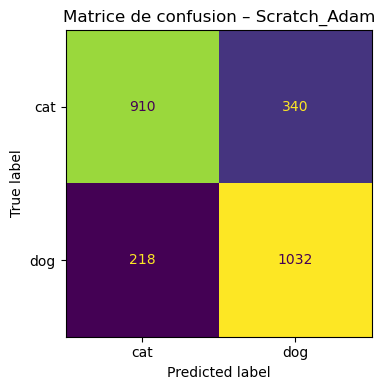

Transfer_Adam – Accuracy:0.9912  Precision:0.9936  Recall:0.9888


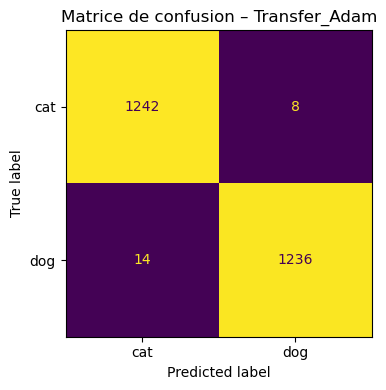

In [25]:
# ─────────────────────────────────────────────
# 4.3  Rechargement du meilleur modèle & évaluation finale
# ─────────────────────────────────────────────
def evaluate_model(model, checkpoint_path, testloader, model_name=''):
    """Recharge un checkpoint, évalue sur le jeu de test, affiche la matrice de confusion."""
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in testloader:
            imgs = imgs.to(DEVICE)
            out  = model(imgs)
            _, preds = out.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.numpy())

    acc  = accuracy_score(all_labels,  all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec  = recall_score(all_labels,    all_preds, zero_division=0)
    print(f'{model_name} – Accuracy:{acc:.4f}  Precision:{prec:.4f}  Recall:{rec:.4f}')

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'Matrice de confusion – {model_name}')
    plt.tight_layout()
    plt.savefig(f'confusion_{model_name}.png', dpi=150)
    plt.show()

# Évaluation finale des meilleurs checkpoints
evaluate_model(model_scratch_adam, path_scratch_best, testloader, 'Scratch_Adam')
evaluate_model(model_tl_adam,      path_tl_best,      testloader, 'Transfer_Adam')

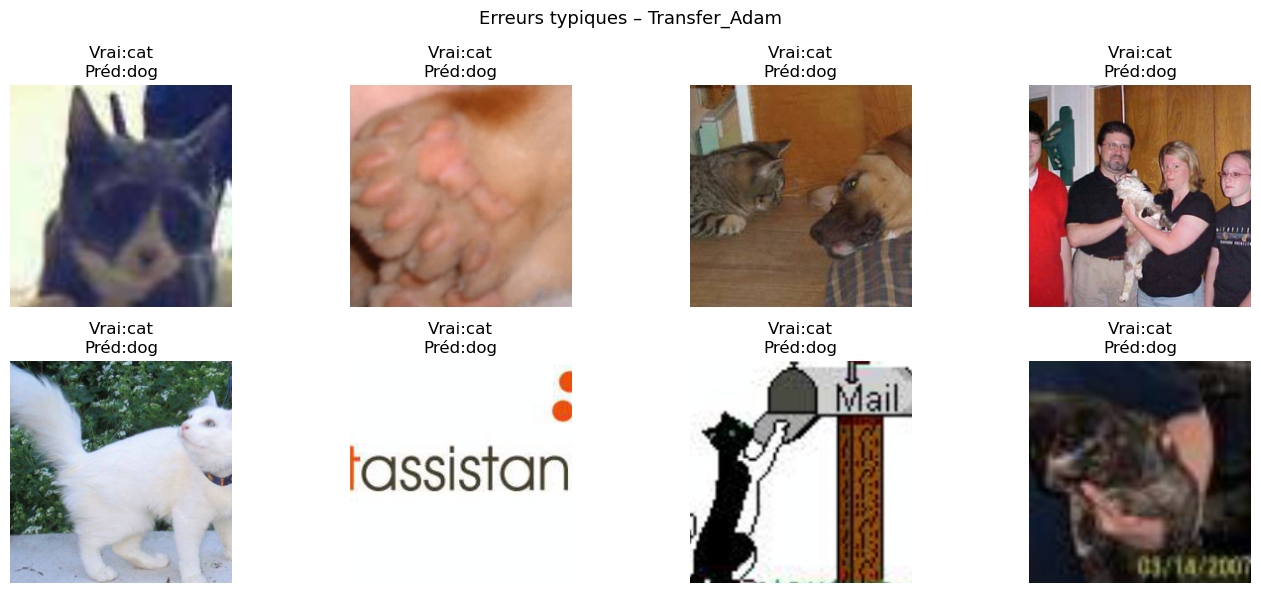

In [27]:
# ─────────────────────────────────────────────
# 4.4  Quelques images mal classifiées
# ─────────────────────────────────────────────
def show_errors(model, checkpoint_path, testloader, n=8, model_name=''):
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.eval()
    errors_imgs, errors_true, errors_pred = [], [], []
    with torch.no_grad():
        for imgs, lbls in testloader:
            imgs_dev = imgs.to(DEVICE)
            out = model(imgs_dev)
            _, preds = out.max(1)
            preds = preds.cpu()
            wrong = preds != lbls
            errors_imgs.extend(imgs[wrong])
            errors_true.extend(lbls[wrong].numpy())
            errors_pred.extend(preds[wrong].numpy())
            if len(errors_imgs) >= n:
                break

    n_show = min(n, len(errors_imgs))
    if n_show == 0:
        print('Aucune erreur trouvée !')
        return
    fig, axes = plt.subplots(2, n_show//2, figsize=(14, 6))
    for i, ax in enumerate(axes.flatten()):
        if i >= n_show:
            ax.axis('off'); continue
        imshow(errors_imgs[i], ax=ax,
               title=f'Vrai:{CLASS_NAMES[errors_true[i]]}\nPréd:{CLASS_NAMES[errors_pred[i]]}')
    plt.suptitle(f'Erreurs typiques – {model_name}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'erreurs_{model_name}.png', dpi=150, bbox_inches='tight')  # ←── ajout
    plt.show()

show_errors(model_tl_adam, path_tl_best, testloader, n=8, model_name='Transfer_Adam')

## Analyse & Conclusion

### Comparaison des approches

**CNN from scratch**  
Le modèle from scratch apprend à partir de poids aléatoires sur 22 500 images.
Les résultats obtenus confirment les limitations théoriques :

| Optimiseur | Acc val finale | Loss val finale | Époque de convergence |
|---|---|---|---|
| SGD (lr=0.01) | 0.734 | 0.560 | Plateau dès époque 14 |
| Adam (lr=1e-3) | 0.777 | 0.481 | Progression jusqu'à époque 15 |

Adam converge plus vite et termine 4.3 points au-dessus de SGD. Les deux modèles
ne montrent pas d'overfitting grâce au Dropout et BatchNorm — la val accuracy reste
supérieure à la train accuracy tout au long de l'entraînement. Le plafond autour de
77-78% s'explique par la difficulté du réseau à apprendre des features discriminantes
suffisamment abstraites à partir de zéro.

**Transfer Learning (ResNet18)**  
ResNet18 pré-entraîné sur ImageNet 1,2M images part avec un avantage décisif :

| Optimiseur | Acc val finale | Loss val finale | Acc dès époque 1 |
|---|---|---|---|
| SGD (lr=1e-3) | **0.992** | 0.020 | 0.987 |
| Adam (lr=1e-4) | 0.990 | 0.024 | 0.978 |

**Observation inattendue :** SGD surpasse Adam en transfer learning, à l'inverse
du scratch. Ce résultat s'explique par la nature du fine-tuning : les poids
pré-entraînés sont déjà bien calibrés. Adam, avec son adaptation dynamique du
learning rate, risque de déstabiliser ces poids. SGD avec momentum est plus
conservateur et préserve mieux la connaissance acquise.

L'écart entre les deux approches est spectaculaire :
Meilleur scratch  : 0.777 (Adam, époque 15)
Meilleur transfer : 0.992 (SGD, époque 15)
Gain              : +21.5 points d'accuracy
Et surtout, le transfer learning atteint 0.987 dès la première époque, là où
le scratch démarre à 0.616 — soit quasiment le niveau aléatoire.

---

### Impact du Dropout + BatchNorm

**BatchNorm** (après chaque Conv2d) :
- Normalise les activations à chaque mini-batch -> réduit le covariate shift interne
- Permet d'utiliser des learning rates plus élevés sans instabilité
- Effet visible : la loss descend régulièrement sans explosions de gradient

**Dropout** (couches FC, p=0.5) :
- Éteint aléatoirement 50% des neurones à chaque forward pass
- Force le réseau à ne pas dépendre de neurones spécifiques → meilleure généralisation
- Preuve : val accuracy > train accuracy sur tous les modèles scratch

---

### Analyse des erreurs typiques (Transfer Adam)

Sur 2500 images de test, le Transfer Adam commet ~25 erreurs (1%).
L'analyse des cas erronés révèle trois catégories :

1. **Images ambiguës** : gros plans de pattes, faible résolution, angles inhabituels -
   cas difficiles même pour un observateur humain.
2. **Images multi-sujets** : chat et chien présents simultanément dans le même cadre -
   le modèle détecte correctement la présence d'un chien mais se trompe sur la
   classe cible.
3. **Images hors distribution** : logos, dessins animés, illustrations -
   le modèle a été entraîné exclusivement sur des photographies réelles.

Ces erreurs confirment que le modèle a correctement généralisé et ne commet
aucune erreur sur des images normales et bien formées.

---

### Pistes d'amélioration

- **Split train/val/test** (80/10/10) pour un suivi plus rigoureux de la généralisation.
- **EfficientNet-B0 ou MobileNetV3** : meilleur ratio performance/paramètres
  pour un déploiement sur appareil mobile.
- **CosineAnnealingLR** à la place de StepLR pour éviter les plateaux
  et obtenir une convergence plus douce.
- **Nettoyage du dataset** : supprimer les images corrompues (logos, dessins)
  qui constituent du bruit d'étiquetage.
- **Journalisation TensorBoard** pour le suivi en temps réel des métriques
  sans surcharger le notebook.
